# Message Queues — Complete Reference

> A message queue is an **asynchronous communication buffer** that decouples producers (who send work)  
> from consumers (who process work), allowing each side to scale and fail independently.

```
Producer ──send & forget──► [ Message Queue ] ──pull & process──► Consumer A
                                                                ──► Consumer B
                                                                ──► Consumer C
```

The producer does not wait for the consumer. The queue holds messages until a consumer is ready.

---

## 1. Messaging Patterns

There are four fundamental patterns, each solving a different communication problem:

### 1.1 Point-to-Point (Competing Consumers)
One message is delivered to **exactly one** consumer. Multiple consumers compete for messages — each message is processed once.

```
Producer ──► [Queue] ──► Consumer A   (Consumer B and C get different messages)
                    ──► Consumer B
                    ──► Consumer C
```
**Use when**: You want to horizontally scale workers processing a task (e.g., image resizing jobs).

---

### 1.2 Pub/Sub (Topic-Based Fan-out)
One message is delivered to **all subscribers** of a topic. Each subscriber gets its own copy.

```
Producer ──► [Topic] ──► Subscriber A  (all three receive the same message)
                    ──► Subscriber B
                    ──► Subscriber C
```
**Use when**: Multiple independent services each need to react to the same event (e.g., an `order.placed` event triggers billing, inventory, and email services simultaneously).

---

### 1.3 Fan-out to Multiple Queues
A single event is published to a topic, which fans out into **multiple independent queues**, each consumed by a different service.

```
Producer ──► [Topic]
               ├──► [Queue A] ──► Billing Service
               ├──► [Queue B] ──► Inventory Service
               └──► [Queue C] ──► Notification Service
```
**Use when**: You need both fan-out delivery AND reliable per-service buffering (SNS → SQS is the AWS canonical pattern for this).

---

### 1.4 Dead Letter Queue (DLQ) Pattern
When a message fails processing after N retries, it is moved to a **Dead Letter Queue** instead of being dropped or blocking the main queue.

```
[Main Queue] ──► Consumer (fails 3x) ──► [Dead Letter Queue]
                                               └──► Alert / manual review / replay
```
**Use when**: You cannot afford to silently lose failed messages.

---

## 2. What Happens When a Consumer Fails Mid-Processing?

A consumer picks a message and crashes before acknowledging it. Each system handles this differently:

| System | Mechanism | How it prevents double-processing |
|---|---|---|
| **SQS** | Visibility timeout (default 30s) | Message becomes invisible to other consumers while being processed; re-appears if not ACK'd in time |
| **Kafka** | Partition assignment + consumer offsets | Each partition is assigned to exactly one consumer in a group; offset only advances on explicit commit |
| **RabbitMQ** | Channel-level prefetch + ACK timeout | Unacknowledged messages are re-queued and re-delivered to another consumer |

---

## 3. Delivery Guarantees

| Guarantee | Meaning | When to use |
|---|---|---|
| **At-most-once** | Message may be lost; never duplicated | Acceptable loss — metrics, analytics pings, live sensor data |
| **At-least-once** | Message delivered one or more times; may be duplicated | Most production systems — pair with **idempotent consumers** to handle duplicates safely |
| **Exactly-once** | Every message processed exactly one time | Theoretically possible with distributed transactions; high complexity and performance cost |

> **Rule of thumb**: Design for **at-least-once + idempotency**. True exactly-once is rarely worth the trade-off.

---

## 4. When to Use a Message Queue?

| Signal | Why a queue helps | Example |
|---|---|---|
| **Async work** | User doesn't need the result immediately | Send email, generate PDF report, process upload |
| **Bursty traffic** | Absorbs traffic spikes without dropping requests or overloading downstream | Flash sale orders, batch imports |
| **Decoupling** | Services scale and fail independently; no direct service-to-service dependency | Order service and inventory service |
| **Reliability** | Can't afford to lose work even if the consumer is temporarily down | Payment processing, audit logging |
| **Rate limiting downstream** | Consumer processes at its own pace regardless of producer rate | Calling a slow 3rd-party API |

### When NOT to use a queue
- You need a **synchronous response** (use direct HTTP/gRPC instead)
- The consumer needs **real-time, low-latency** results (sub-10ms)
- The workflow is **simple and co-located** — a queue adds unnecessary overhead

---

## 5. Common Deep Dives (Interview Questions)

---

### Q1: How do you handle increased throughput?

**Answer**: Add partitions and scale consumers in parallel.

```
Topic: "orders"
─────────────────────────────────────────────────────
Partition 0  [msg1, msg4, msg7] ──► Consumer A
Partition 1  [msg2, msg5, msg8] ──► Consumer B
Partition 2  [msg3, msg6, msg9] ──► Consumer C
─────────────────────────────────────────────────────
```

Key rules:
- Messages with the **same partition key** always go to the same partition — preserving order per key (e.g., all events for `user_id=42` go to partition 0)
- **One consumer per partition** per consumer group — prevents double-processing
- **You cannot have more consumers than partitions** — extra consumers sit idle
- To scale further: increase partition count and add consumers proportionally

---

### Q2: What happens when the queue is full?

Three strategies (choose based on criticality):

| Strategy | How | Trade-off |
|---|---|---|
| **Scale out** | Add more partitions, queue capacity, and consumers | Preferred — no data loss, but needs headroom |
| **Back-pressure / rejection** | Queue returns an error to the producer; producer slows down or retries | Producer must handle 429s gracefully |
| **Monitoring + alerting** | Trigger alerts on queue depth metric; human/auto intervention | Always do this alongside the above |

---

### Q3: What happens when a message keeps failing?

**Retry with exponential backoff → Dead Letter Queue (DLQ)**

```
Message ──► Consumer (fail) ──► retry #1 (1s)
                           ──► retry #2 (2s)
                           ──► retry #3 (4s)
                           ──► [Dead Letter Queue]
                                     └──► alert / manual inspection / replay after fix
```

- DLQ prevents a poison-pill message from blocking the entire queue
- Always set a **max retry count** and a **DLQ alarm**
- After fixing the bug, messages in the DLQ can be **replayed** back into the main queue

---

### Q4: What happens if the queue itself goes down?

- Run queues with **replication** (Kafka: replication factor ≥ 3; SQS: multi-AZ by default)
- **Leader election**: if the broker leader fails, a follower is promoted automatically
- Producers should **retry with backoff** on connection failures
- For cross-region disaster recovery: replicate queues across regions (Kafka MirrorMaker, SQS with S3 archival)

---

## 6. Queue Technologies Compared

---

### 6.1 Apache Kafka

A **distributed, durable event streaming platform** — designed for high-throughput, replayable, ordered event logs.

**Architecture**:
```
Producers ──► [Broker Cluster]
                  Topic: "orders"
                  ├── Partition 0 (Leader: Broker 1, Replica: Broker 2)
                  ├── Partition 1 (Leader: Broker 2, Replica: Broker 3)
                  └── Partition 2 (Leader: Broker 3, Replica: Broker 1)
                       │
              Consumer Group "billing"       Consumer Group "analytics"
              ├── Consumer A (partition 0)   ├── Consumer X (partition 0)
              ├── Consumer B (partition 1)   ├── Consumer Y (partition 1)
              └── Consumer C (partition 2)   └── Consumer Z (partition 2)
```

| Property | Detail |
|---|---|
| **Ordering** | Guaranteed per partition; use partition key for per-entity ordering |
| **Persistence** | Writes to disk; configurable retention (days/weeks) |
| **Replay** | Yes — consumers track their own offset and can rewind |
| **Consumer groups** | Multiple independent groups each read the full stream |
| **Delivery** | At-least-once (default); exactly-once with transactions |
| **Throughput** | Very high — millions of events/sec |
| **Operations** | Self-managed; higher complexity (ZooKeeper/KRaft) |

**Real-world users**: Netflix (recommendations, billing), Uber (real-time pricing, fraud detection), LinkedIn (feed, messaging)

---

### 6.2 Amazon SQS

A **fully managed, serverless queue** — AWS's hosted alternative. Zero infrastructure to manage.

**Two flavours**:

| Type | Ordering | Throughput | Deduplication |
|---|---|---|---|
| **Standard** | Best-effort (may be out of order) | Unlimited (nearly) | At-least-once (possible duplicates) |
| **FIFO** | Strict first-in, first-out | 3,000 msg/sec with batching | Exactly-once within a 5-min window |

**Key mechanics**:
- **Visibility timeout** (default 30s): message hidden from other consumers while one processes it; re-queues if not deleted in time
- **Long polling**: consumer waits up to 20s for a message instead of hammering empty queue
- **DLQ**: natively supported; configure `maxReceiveCount` threshold

**Common pattern** — SNS → SQS fan-out:
```
Event ──► SNS Topic ──► SQS Queue A ──► Service A
                   ──► SQS Queue B ──► Service B
                   ──► SQS Queue C ──► Service C
```
Each service gets its own queue (independent scaling, independent DLQ, no head-of-line blocking between services).

---

### 6.3 RabbitMQ

A **broker-centric message queue** with sophisticated routing logic built into the broker itself.

**Architecture**:
```
Producer ──► [Exchange]
               │  (routing logic lives here)
               ├──► [Queue A] ──► Consumer A
               ├──► [Queue B] ──► Consumer B
               └──► [Queue C] ──► Consumer C
```

**Exchange types** (routing strategies):
| Type | Routing rule |
|---|---|
| **Direct** | Route by exact routing key match |
| **Topic** | Route by pattern (e.g., `order.*`, `*.error`) |
| **Fanout** | Broadcast to all bound queues |
| **Headers** | Route by message header attributes |

| Property | Detail |
|---|---|
| **Ordering** | Guaranteed with a single consumer per queue; not guaranteed with multiple consumers |
| **Persistence** | Message deleted permanently after ACK (no replay) |
| **Replay** | Not supported |
| **Delivery** | At-least-once |
| **Throughput** | Moderate — good for task queues, not high-volume streams |
| **Operations** | Simpler than Kafka; self-managed |

**Real-world users**: Instagram (photo upload processing), Reddit (comment threads, karma calculation)

---

## 7. RabbitMQ vs Kafka — Decision Guide

| Dimension | RabbitMQ | Kafka |
|---|---|---|
| **Ordering** | Global ordering with 1 consumer; no guarantee with multiple | Per-partition ordering; parallel consumers, ordered per key |
| **Message retention** | Deleted after ACK — one consumer consumes it | Retained for configured period; any consumer group can read |
| **Replay** | No | Yes — rewind offset to any point |
| **Multiple readers** | No — only one consumer reads a message | Yes — multiple consumer groups, each reads the full stream |
| **Delivery guarantee** | At-least-once | At-least-once (default); exactly-once (with transactions) |
| **Routing logic** | Rich — exchange types, bindings, routing keys | Simple — topic + partition key |
| **Throughput** | Moderate | Very high |
| **Latency** | Very low (sub-ms) | Low (ms range) |
| **Complexity** | Lower | Higher |

### Choose RabbitMQ when:
- Task queues and background jobs (emails, notifications, webhooks)
- You need **smart routing** — route different message types to different queues
- Low-to-moderate scale with simple operations
- Each message should be consumed by **exactly one service** and then discarded

### Choose Kafka when:
- **Multiple services** need to independently consume the same events (analytics, billing, audit)
- You need **replay** — re-process historical events after a bug fix or new service launch
- **Massive scale** — high-throughput event ingestion
- Building an **event-sourced** or **audit-log** system where history is first-class

---

## 8. Quick-Reference Summary

```
Need guaranteed delivery + workers scale independently?  ──► Any queue

Need replay / multiple independent readers?              ──► Kafka

Need managed, no-ops?                                    ──► SQS (+ SNS for fan-out)

Need smart routing / low latency task queue?             ──► RabbitMQ

Need real-time broadcast (no persistence)?               ──► Redis Pub/Sub

Need durable event log with consumer groups in Redis?    ──► Redis Streams
```
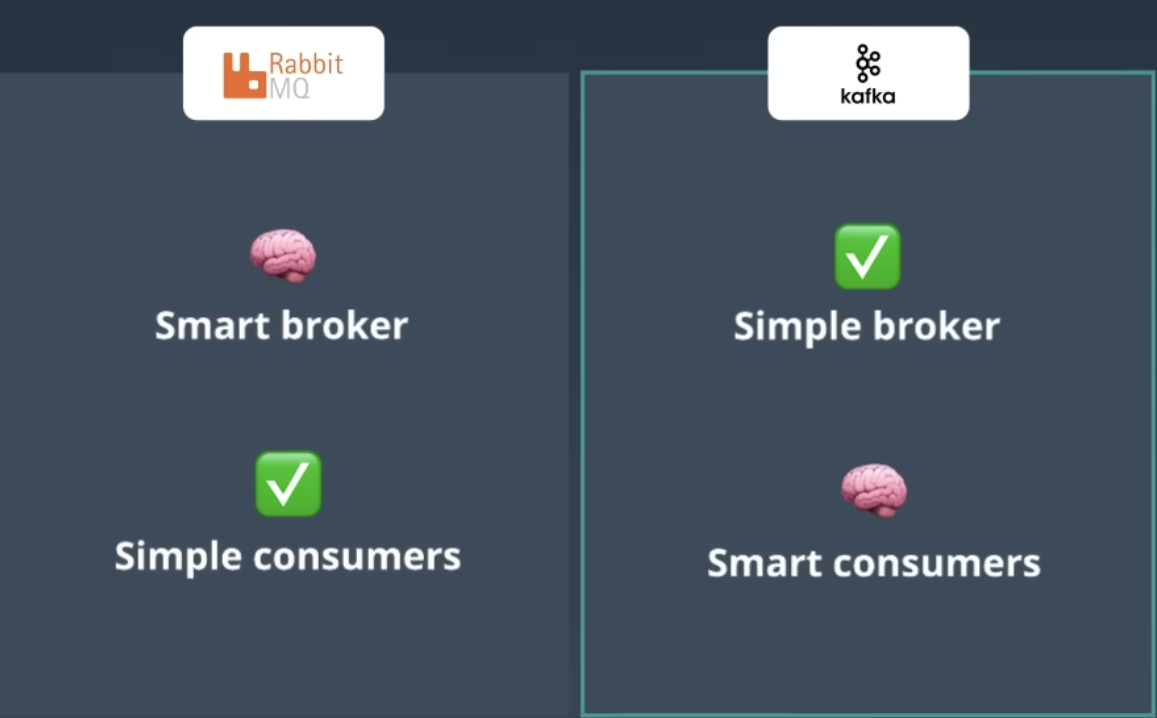